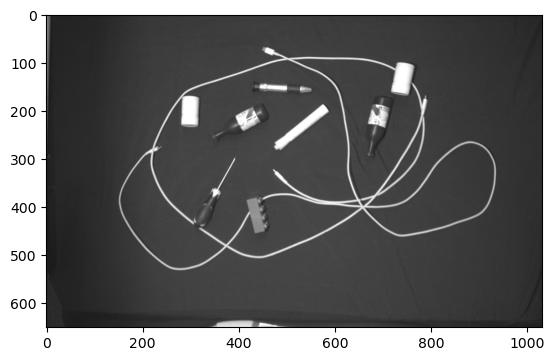

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch

im_frame2 = Image.open('/home/justinyu/multicable-decluttering/decluttering/scripts/test/raw_images/intensity_image2024-06-25T22:27:15.207858.png')
np_frame2 = np.array(im_frame2)

# remove alpha channel
np_frame2 = np_frame2[0:650, :, :3]
# tt_frame2 = torch.tensor(np_frame2).to(torch.uint8)
plt.imshow(np_frame2)


(650, 1032, 3)


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


Endpoint detection took 2.4108383655548096 seconds


/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1656352465323/work/aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


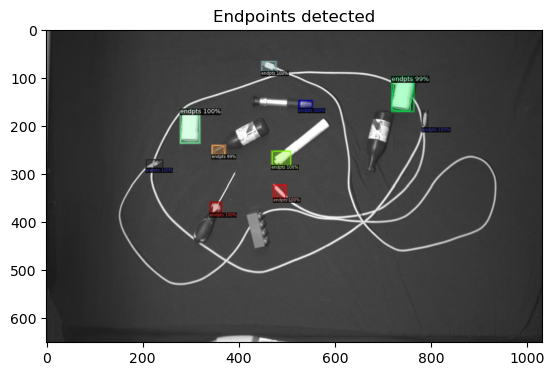

(650, 1032, 3)
[[ 77 463]
 [279 225]
 [336 486]
 [370 352]
 [156 539]
 [201 299]
 [187 787]
 [267 489]
 [250 358]
 [134 741]]


<Figure size 640x480 with 0 Axes>

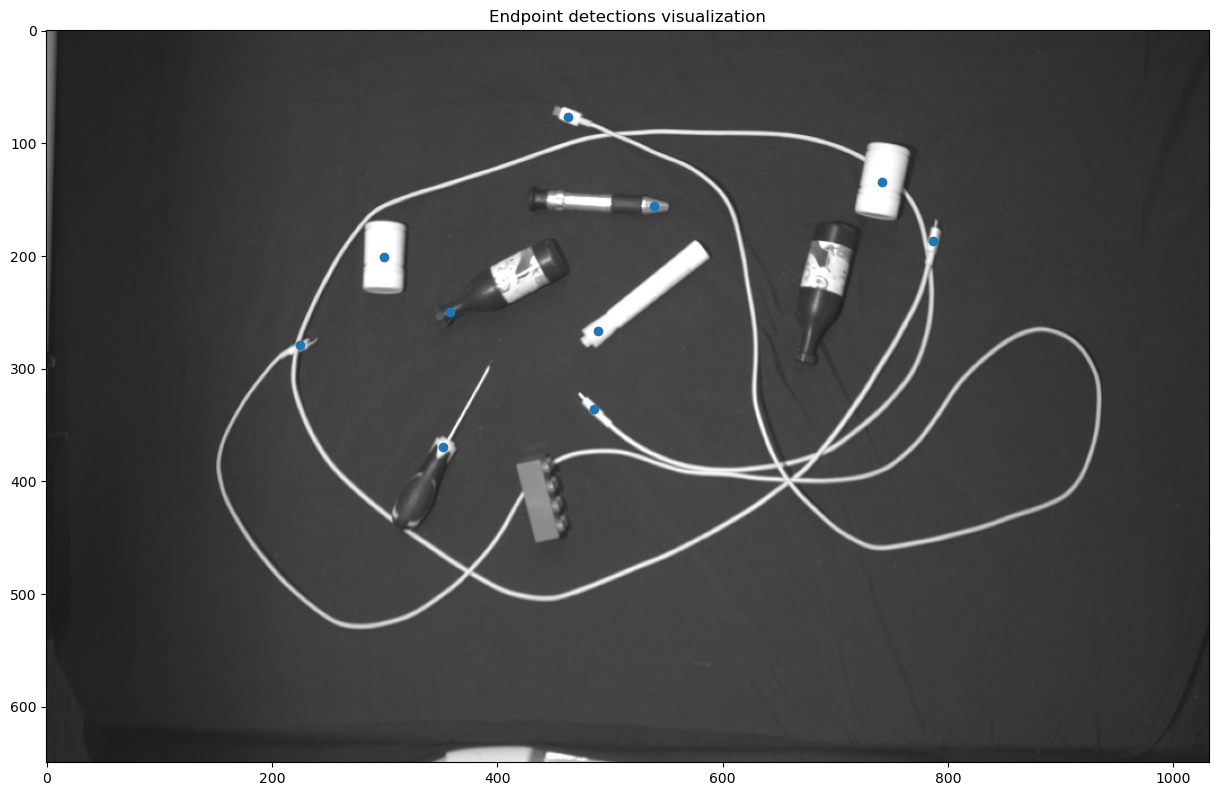

In [2]:
img = np_frame2
from decluttering.data.detectron2_repo import analysis as loop_detectron
import numpy as np 
import time

def get_endpoints(img):
    # model not used, already specified in loop_detectron
    # self.img = self.iface.take_image()
    endpoint_start = time.time()
    endpoint_boxes, out_viz = loop_detectron.predict(img, thresh=0.99, endpoints=True)
    endpoint_end = time.time()
    print("Endpoint detection took {} seconds".format(endpoint_end - endpoint_start))
    plt.clf()
    plt.imshow(out_viz)
    plt.title("Endpoints detected")
    plt.show()
    plt.imsave("/home/justinyu/multicable-decluttering/misc_images/endpoints_detected.png", out_viz)
    print(out_viz.shape)
    # show_img()

    endpoints = []
    for i, box in enumerate(endpoint_boxes):
        xmin, ymin, xmax, ymax = box
        x = (xmin + xmax)/2
        y = (ymin + ymax)/2

        # print(xmin.astype(np.int32))
        # plt.clf()
        # plt.imshow(img[ymin.astype(np.int32):ymax.astype(np.int32), xmin.astype(np.int32):xmax.astype(np.int32)])
        # plt.show()
        # plt.imsave(f"/home/justinyu/multicable-decluttering/misc_images/endpoints_crop{i}.png", img[ymin.astype(np.int32):ymax.astype(np.int32), xmin.astype(np.int32):xmax.astype(np.int32)])
        # new_yx = self.closest_valid_point(self.img.color._data, self.img.depth._data, np.array([y,x]))
        # print(x)
        # print(y)
        # endpoints.append([new_yx, new_yx])
        endpoints.append([y, x])   
    endpoints = np.array(endpoints).astype(np.int32)
    print(endpoints)
    # # (n,2,2) (num endpoints, (head point, neck point), (x,y))
    # endpoints = np.array([e for e in endpoints if self.img.depth._data[e[0][0], e[0][1]] > 0])
    # self.logger.debug("Found {} true endpoints after filtering for depth".format(len(endpoints)))

    plt.clf()
    plt.figure(figsize=(15,18))
    plt.title("Endpoint detections visualization")
    plt.imshow(img)
    if len(endpoints) > 0:
        plt.scatter(endpoints[:, 1], endpoints[:, 0])
    plt.show()
    # plt.imsave("/home/justinyu/multicable-decluttering/misc_images/endpoints_detected_with_clutter.png", img)
    # self.show_img()

    # endpoints = endpoints.astype(np.int32).reshape(-1, 2, 2)
    # # endpoint1 = endpoints[0][0]
    # # endpoint2 = endpoints[1][0]
    # self.endpoints = endpoints[:, 0, :] #np.array([endpoint1, endpoint2])
    return endpoints

print(img.shape)
endpts = get_endpoints(img)

/home/mallika/anaconda3/envs/lipnew/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Resetting zs_weight datasets/metadata/lvis_v1_clip_a+cname.npy
Inference time:  0.06309151649475098
Number of masks before filtering torch.Size([13, 1, 650, 1032])
Area of masks before filtering tensor([  1970,   3869,   4285,   2576,   2724,   2150,   2381,   2592,   2359,
           304,    846, 119911, 572612], device='cuda:0')
torch.Size([10, 1, 650, 1032])


/home/justinyu/multicable-decluttering/decluttering/data/detectron2_repo/detectron2/structures/image_list.py:99: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


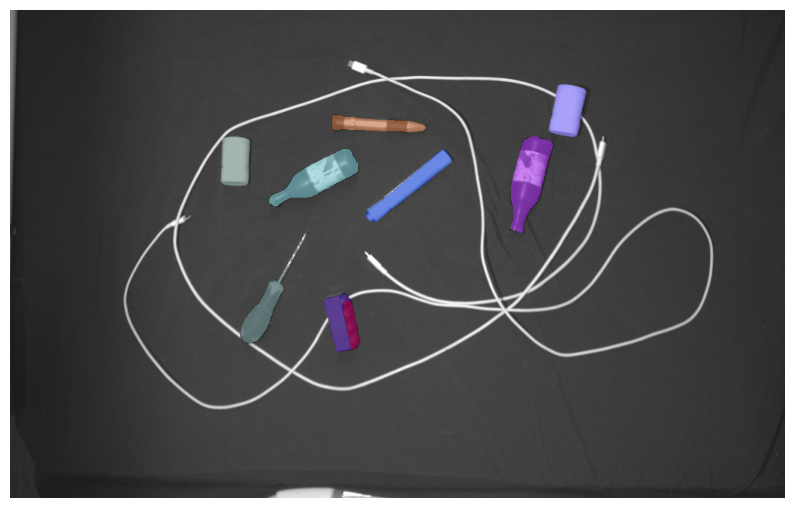

In [3]:
from decluttering.data.utils.detic_dataloader import DeticDataloader

detic = DeticDataloader()
detic.create()
detic.default_vocab()
out = detic.predict(np_frame2)
import torch
num_masks = out['masks'].shape[0]
print("Number of masks before filtering", out['masks'].shape)
print("Area of masks before filtering", torch.sum(out['masks'], dim = (1,2,3)))

def filter_mask_by_area(masks, max_area = 10000, min_area = 500):
    """
    Filter masks by area
    """
    mask_areas = torch.sum(masks, dim = (1,2,3))
    mask_areas = mask_areas.cpu().numpy()
    mask_areas = mask_areas.reshape(-1)
    masks_filtered = masks[(mask_areas < max_area) & (min_area < mask_areas)]
    return masks_filtered

filtered_areas = filter_mask_by_area(out['masks'])
print(filtered_areas.shape)
num_masks = filtered_areas.shape[0]

detic.visualize_output(np_frame2, filtered_areas, image_save_path=f"detic_masks/filtered_masks{time}.png")

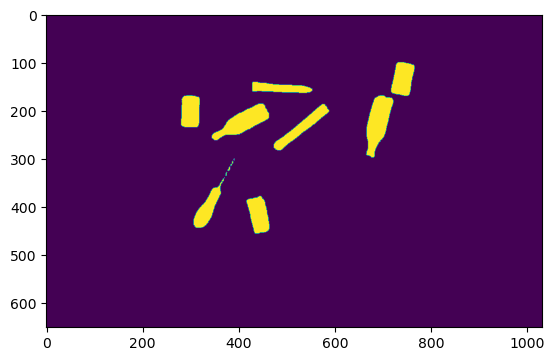

In [12]:
def combine_masks(masks):
    """
    Combine masks into a single mask
    """
    ones = torch.ones(masks[0].shape).to(masks.device)
    combined_mask = torch.minimum(torch.sum(masks, dim = 0), ones).squeeze(0)
    return combined_mask

plt.imshow(combine_masks(filtered_areas).cpu().numpy())

In [18]:
def filter_endpoint_centers(combined_mask, endpoints):
    # Filter out endpoints that fall inside of a clutter object mask
    # combined_mask shape is (H, W)
    # endpoints is a list of shape (n, 2) (num endpoints, (x,y)) i.e. [[ 77 463] [279 225] [336 486] [370 352]]
    endpoint_centers = []
    for endpoint in endpoints:
        y, x = endpoint
        if combined_mask[y, x] == 0:
            endpoint_centers.append(endpoint)
    return endpoint_centers

print(endpts)
filtered_endpoint_centers = np.array(filter_endpoint_centers(combine_masks(filtered_areas), endpts))

[[ 77 463]
 [279 225]
 [336 486]
 [370 352]
 [156 539]
 [201 299]
 [187 787]
 [267 489]
 [250 358]
 [134 741]]


<Figure size 640x480 with 0 Axes>

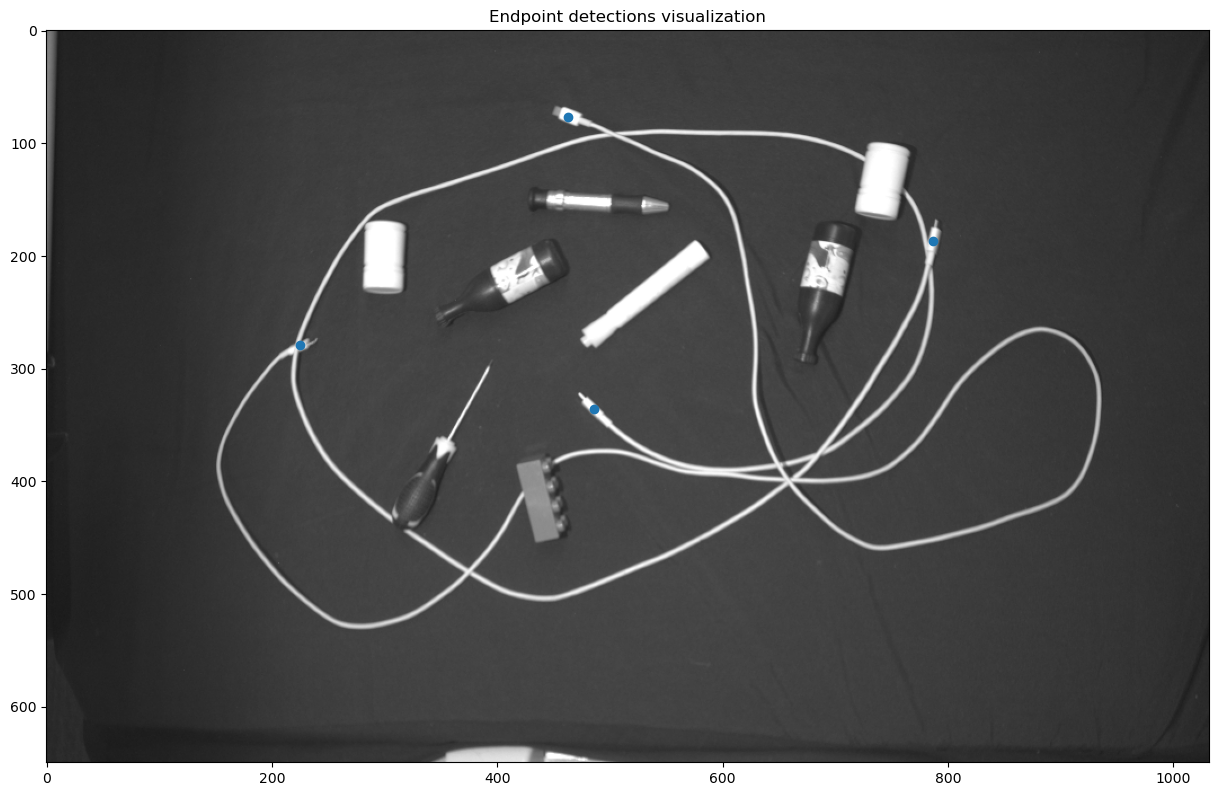

In [19]:

plt.clf()
plt.figure(figsize=(15,18))
plt.title("Endpoint detections visualization")
plt.imshow(img)
if len(filtered_endpoint_centers) > 0:
    plt.scatter(filtered_endpoint_centers[:, 1], filtered_endpoint_centers[:, 0])
plt.show()

In [22]:
from decluttering.data.tracer.analytic_tracer.simple_uncertain_trace_single import trace

def get_trace_from_endpoint(img, point):
        # trace from endpoint on image
        # img = np.concatenate((img.color._data, self.img.depth._data), axis=-1)
        # img[-130:, ...] = 0
        # thresh_img = np.where(img[:,:,:3] > 100, 255, 0)

        # full_img = np.concatenate((thresh_img, img[:,:,3:]), axis=-1)

        # path, finished_paths = trace(full_img, point, None, exact_path_len=4, viz=self.viz)
        path, finished_paths = trace(img, point, exact_path_len=3, viz=False)
        agree_point = tuple(np.array([point[0], point[1]]).astype(np.int32))
        if path is None:
            if len(finished_paths) > 0:
                min_len_path = float('inf')
                for fp in finished_paths:
                    if len(fp) < min_len_path:
                        min_len_path = len(fp)
                for i in range(min_len_path):
                    values = np.array([list(fp[i]) for fp in finished_paths])
                    x = values[:, 0]
                    y = values[:, 1]
                    x_diff = np.max(x)-np.min(x)
                    y_diff = np.max(y)-np.min(y)
                    if x_diff < 5 and y_diff < 5:
                        agree_point = values[0]
            return agree_point, True
        return path, False



In [23]:
random_endpt = np.random.permutation(len(endpts))[0]

print(np.array(endpts[random_endpt]))

starting_pixels = get_trace_from_endpoint(img, np.array(endpts[0]))

[279 225]


In [24]:
from decluttering.data.tracer.blip_pipeline.tracer import run_tracer_with_transform

# run_tracer_with_transform(img, endpts, depth)
# print(starting_pixels[0])
run_tracer_with_transform(img, starting_pixels[0], endpoints=endpts, sample=True, start_time=None, viz = True)

[ 77 463]
[ 80.87075033 478.52473162]
[ 86.86445582 493.35967329]
[ 94.37600083 507.48683478]


((array([[ 81, 479],
         [ 87, 493],
         [ 94, 507],
         [ 81, 479],
         [ 87, 493],
         [ 94, 507],
         [100, 521],
         [106, 534],
         [112, 547],
         [117, 560],
         [123, 573],
         [131, 584],
         [140, 595],
         [151, 604],
         [165, 611],
         [180, 615],
         [195, 618],
         [210, 621],
         [225, 623],
         [239, 625],
         [253, 627],
         [267, 629],
         [281, 630],
         [295, 630],
         [309, 629],
         [323, 630],
         [338, 632],
         [352, 636],
         [366, 641],
         [380, 647],
         [393, 654],
         [404, 662],
         [415, 671],
         [425, 681],
         [434, 692],
         [443, 703],
         [451, 715],
         [457, 728],
         [459, 742],
         [457, 756],
         [455, 769],
         [452, 783],
         [449, 797],
         [446, 811],
         [442, 825],
         [438, 839],
         [433, 852],
         [429